In [1]:
from data_utils import index_segmentations_df
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
import torch.nn as nn
import torch
from random_disconnections.visualisation_utils import visualize_first_n_with_branch_cuts
from segmentation_training import SegmentationDataset
from random_disconnections.random_disconnections_albumentation import  MyTestTransform

Load data

In [2]:
SEGMENTATIONS_DIR = Path.cwd().parents[2] / "AnnotationsData" / "Segmentations"


path_df = index_segmentations_df(
    SEGMENTATIONS_DIR,
    mask_name = 'calculated_masks'
)

mask_quality_df = pd.read_csv('mask_quality_summary.csv')
mask_quality_df = mask_quality_df[['image_path', 'mask_quality']]


mask_quality_df["image_path"] = mask_quality_df["image_path"].apply(Path)

path_df = path_df.merge(mask_quality_df, on = 'image_path', how = 'inner')
print(path_df.columns)

# Only segment the entire cell ie. not just the SOMA
path_df = path_df[path_df['class'] == 'MG_whole']
# Remove all bad annotations
path_df = path_df[~path_df['mask_quality'].isin(['bad', 'bad_image_quality', 'disagree'])]

# path_df = path_df.merg(mask_quality_df, on = )
# Only take first 100 for now to train fast
# path_df = path_df.head(160)
print(len(path_df), "annotation pairs found")


    # First split: train + temp (val+test)
train_df, temp_df = train_test_split(
    path_df,
    test_size=0.3,        # 70% train, 30% temp
    random_state=42,
    shuffle=True
)

# Second split: val + test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,        # 15% val, 15% test
    random_state=42,
    shuffle=True
)

print('Training, validatoin and testing sizes')
print(len(train_df), len(val_df), len(test_df))



train_tfms = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2()
])

test_tfms = A.Compose([
    A.Resize(256, 256),
    ToTensorV2(), 
    MyTestTransform(p = 1.0)
])



train_ds = SegmentationDataset(train_df, train_tfms)
test_ds  = SegmentationDataset(test_df, test_tfms)
val_ds = SegmentationDataset(val_df, test_tfms)


train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=2, shuffle=False, num_workers=0)


criterion = nn.BCEWithLogitsLoss()
# criterion = DiceLoss()

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'currently using device: {device}')

Index(['scan', 'class', 'image_path', 'mask_path', 'mask_quality'], dtype='object')
967 annotation pairs found
Training, validatoin and testing sizes
676 145 146
currently using device: cpu


bruh
bruh


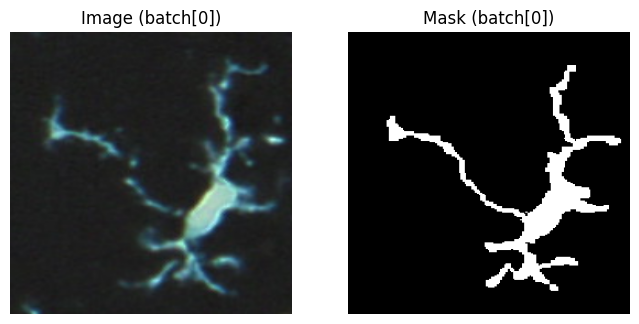

In [3]:
import matplotlib.pyplot as plt

img_batch, mask_batch = next(iter(test_loader))

# take first item in batch
img = img_batch[0].permute(1, 2, 0).numpy()
mask = mask_batch[0, 0].numpy()

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Image (batch[0])")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap="gray")
plt.title("Mask (batch[0])")
plt.axis("off")

plt.show()



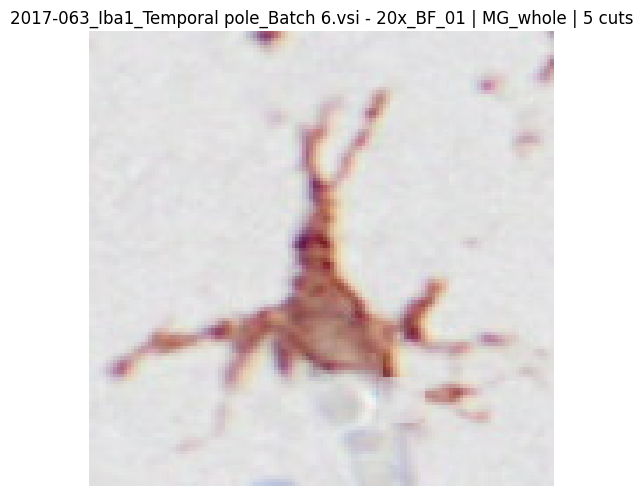

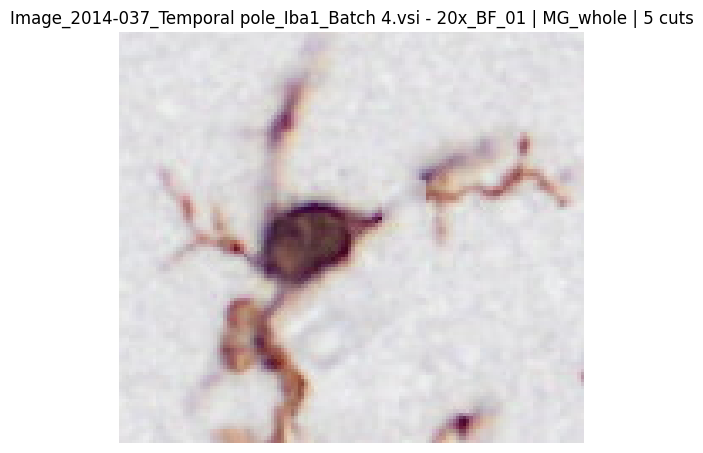

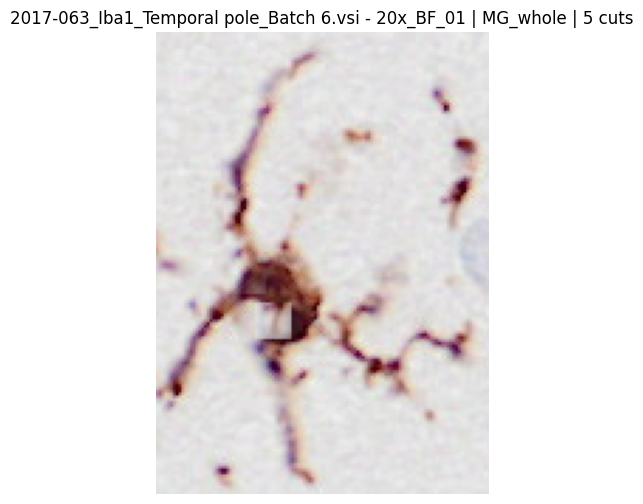

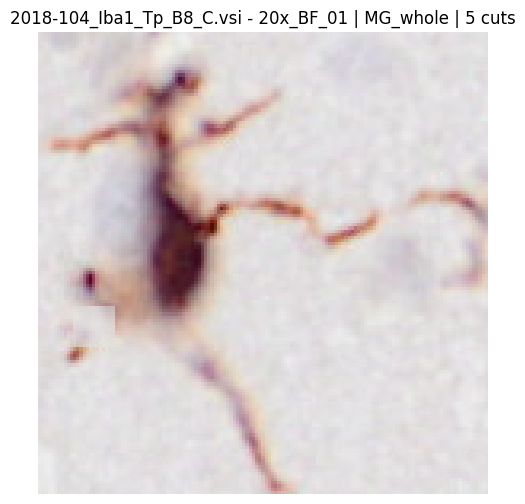

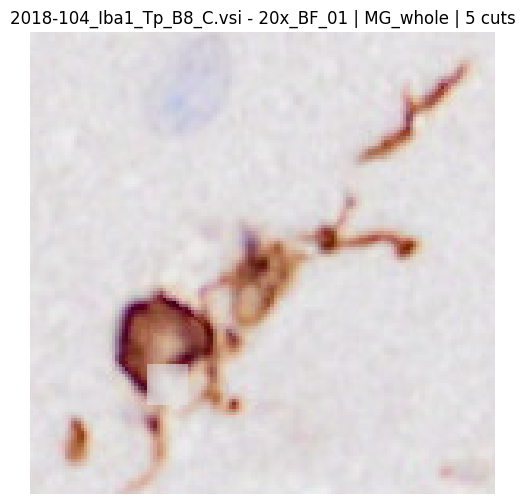

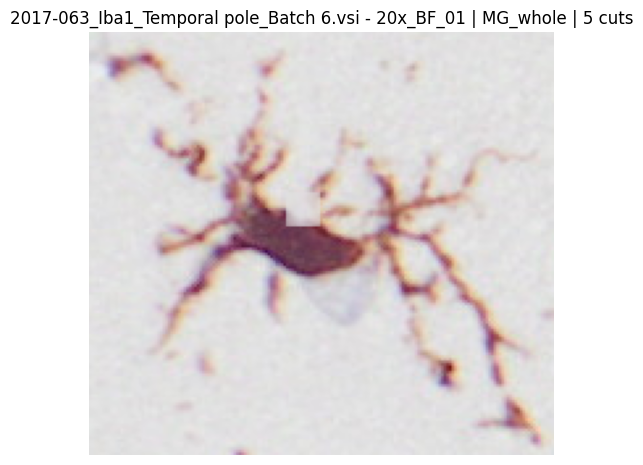

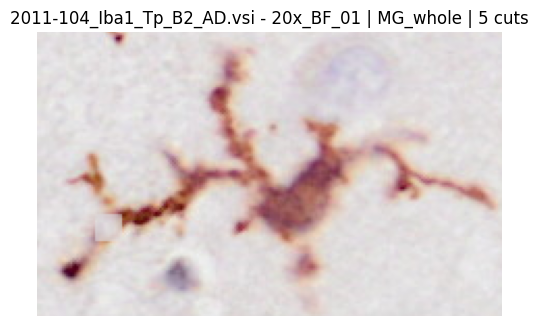

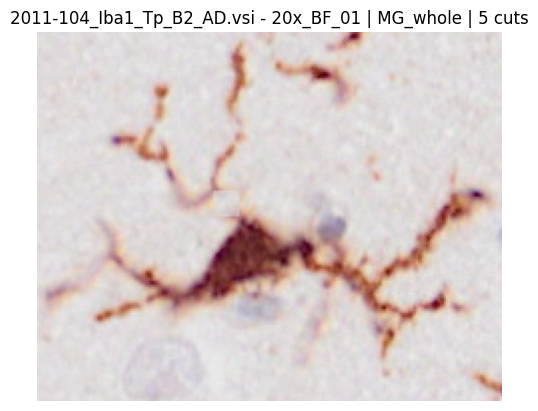

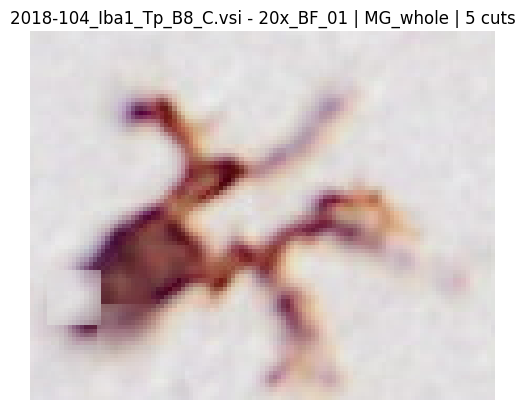

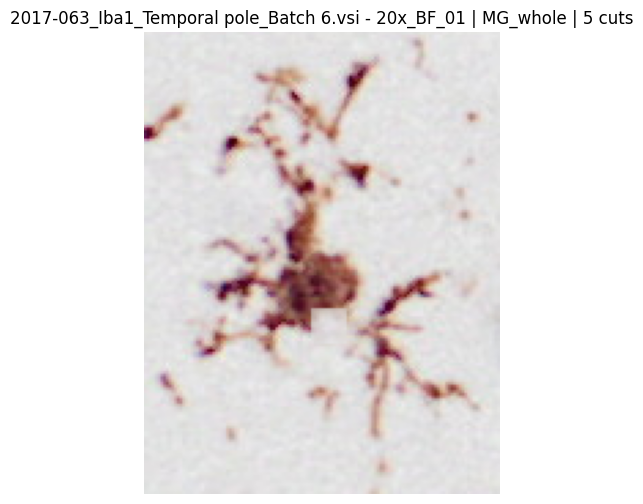

In [3]:
visualize_first_n_with_branch_cuts(
    train_df,
    n=10,
    box_size = 12,
    show_points=False,
    blur_output = True, 
    replace_full_box=True
)
